## This notebook is used to reproduce the results in 4.4

Successfully imported src.projection
--- Processing ECDSA ---
Analysis time: 7.68 seconds


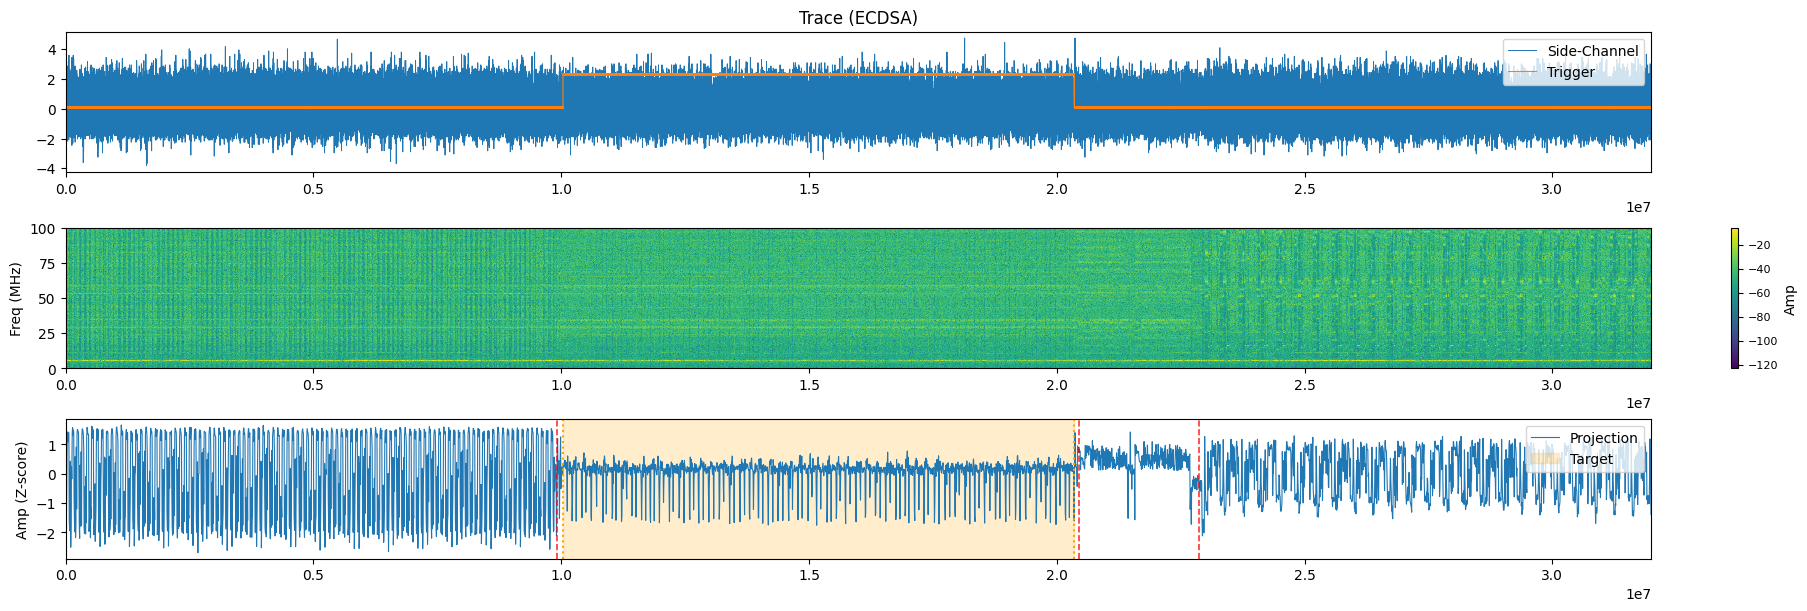

In [1]:
import os
import sys
sys.path.append(os.path.abspath(''))
from src.cpd import *
import numpy as np
import random
import time

# for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Define Configs
configs = [
    DatasetConfig(
            name="ECDSA",
            signal_path="./dataset/trace-copilot/ecdsa/ECDSA_trace.npy",
            trigger_path="./dataset/trace-copilot/ecdsa/ECDSA_trigger.npy",
            window=10000,

            # following parameters are used for evaluation, never used to analysis
            fs=200.0e6,
            target_interval=(10036211, 20357189),
            noise_std=0
        ),
]

# Run Pipeline
for config in configs:
    t0 = time.time()
    print(f"--- Processing {config.name} ---")
    data = process_trace(config)
    if data:
        if config.target_interval:
            evaluate_segmentation(data['change_points_samples'], config.target_interval)
        
        t1 = time.time()
        print(f"Analysis time: {t1 - t0:.2f} seconds")
        
        plot_results(data)


In [2]:
run_window_experiment()


==================== Experiment 1: Window Size ====================
Processing Window: 1000...
Processing Window: 5000...
Processing Window: 10000...
Processing Window: 15000...
Processing Window: 20000...

--- Window Experiment Results ---
Window     | Start Ratio     | End Ratio      
1000       | 0.015620        | 0.020692
5000       | 0.016589        | 0.000030
10000      | 0.011986        | 0.008266
15000      | 0.015741        | 0.000151
20000      | 0.026762        | 0.000757


In [4]:
df_runs, df_summary = run_noise_experiment(repeat=10, base_seed=42, plot_each=False)



==================== Experiment 2: Noise Levels (repeat=10, base_seed=42) ====================

--- Noise Std: 0.5 (variance=0.250) ---
Rep 00 | seed=4115233052 | start_ratio=0.011986 | end_ratio=0.008992
Rep 01 | seed=2955255544 | start_ratio=0.011986 | end_ratio=0.010446
Rep 02 | seed=3943283656 | start_ratio=0.011986 | end_ratio=0.009719
Rep 03 | seed=697296208  | start_ratio=0.011986 | end_ratio=0.010446
Rep 04 | seed=3821139082 | start_ratio=0.011986 | end_ratio=0.010446
Rep 05 | seed=1885069862 | start_ratio=0.011986 | end_ratio=0.009719
Rep 06 | seed=1739687484 | start_ratio=0.011986 | end_ratio=0.006086
Rep 07 | seed=806906839  | start_ratio=0.011986 | end_ratio=0.008266
Rep 08 | seed=536478246  | start_ratio=0.011986 | end_ratio=0.010446
Rep 09 | seed=84605813   | start_ratio=0.011986 | end_ratio=0.009719

--- Noise Std: 1.0 (variance=1.000) ---
Rep 00 | seed=505286199  | start_ratio=0.011260 | end_ratio=0.005359
Rep 01 | seed=150129527  | start_ratio=0.011986 | end_ratio=0.0